Agora, com todas as informaçôes reunidas, vamos começar a análise fazendo uma organização no csv final nas categorias que vamos investigar.

In [1]:
import pandas as pd

In [2]:
df_oscar = pd.read_csv('datasets/oscar_imdb_merged.csv')
df_oscar['sexual_orientation'].value_counts(dropna=False)

sexual_orientation
Straight             422
Bisexual              21
Na                    10
Gay                    7
Matter of Dispute      3
Lesbian                2
Name: count, dtype: int64

Aqui eu vejo a quantidade total de pessoas no csv e o total de cada categoria que eu quero:

In [3]:
df_oscar['race_ethnicity'].value_counts(dropna=False)

race_ethnicity
White             417
Black              21
Hispanic           13
Asian               9
Multiracial         3
Middle Eastern      2
Name: count, dtype: int64

In [4]:
df_oscar.shape

(465, 36)

Agora vamos para a análise gráfica:

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

Para fazer a análise de década, garanto que "year_edition" é numérico e faço a transformação p década, ex: 2023, divido inteiramente por 10 = 202, multiplico por 10 = 2020, e a validação evita erros.

In [6]:
df = pd.read_csv('datasets/oscar_imdb_merged.csv')

df['year_edition'] = pd.to_numeric(df['year_edition'], errors='coerce').fillna(0).astype(int)

df['decade'] = (df['year_edition'] // 10) * 10
df_valid = df[df['decade'] >= 1920].copy()

Proporção racial dos vencedores por década

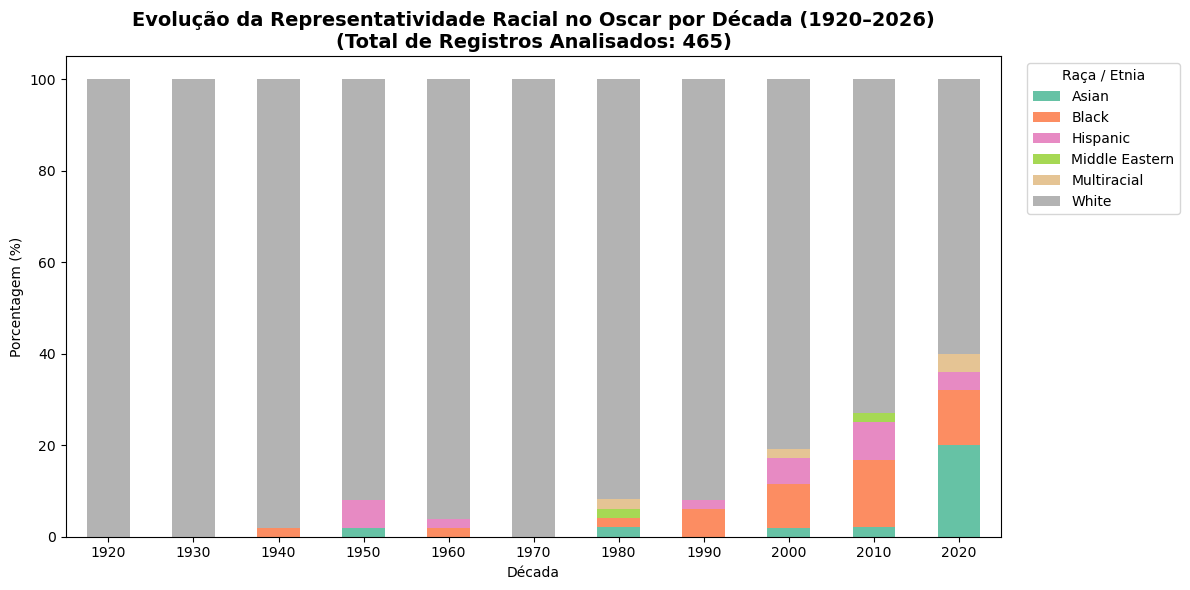

In [7]:
total = len(df_valid)

crosstab_race = pd.crosstab(df_valid['decade'], df_valid['race_ethnicity'], normalize='index') * 100

ax = crosstab_race.plot(kind='bar', stacked=True, figsize=(12, 6), colormap='Set2')
plt.title(f'Evolução da Representatividade Racial no Oscar por Década (1920–2026)\n(Total de Registros Analisados: {total})', fontsize=14, fontweight='bold')
plt.xlabel('Década')
plt.ylabel('Porcentagem (%)')
plt.legend(title='Raça / Etnia', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Distribuição da representatividade por categoria de premiação

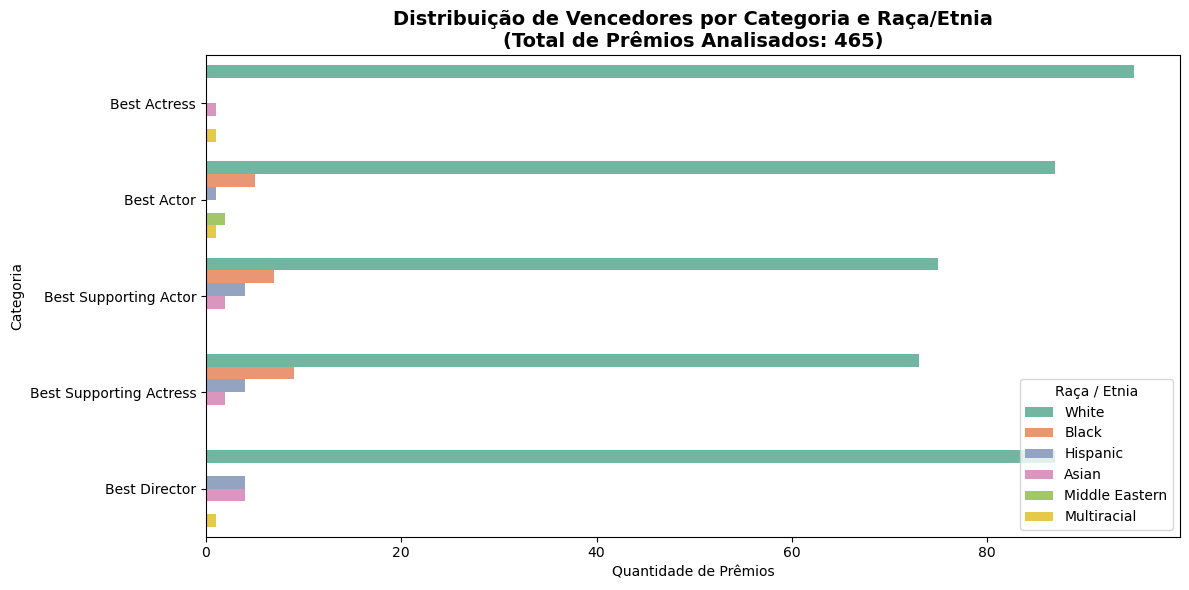

In [8]:
plt.figure(figsize=(12, 6))

sns.countplot(data=df, y='category', hue='race_ethnicity', palette='Set2')
plt.title(f'Distribuição de Vencedores por Categoria e Raça/Etnia\n(Total de Prêmios Analisados: {total})', fontsize=14, fontweight='bold')
plt.xlabel('Quantidade de Prêmios')
plt.ylabel('Categoria')
plt.legend(title='Raça / Etnia', loc='lower right')
plt.tight_layout()
plt.show()

comparar a idade média em que homens e mulheres vencem o Oscar nas categorias de atuação.

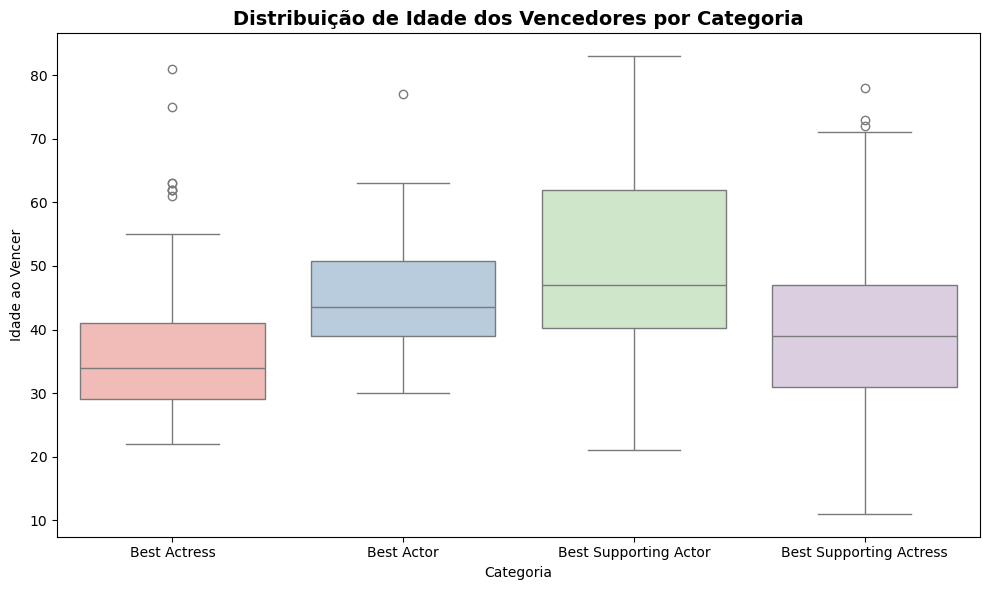

In [12]:
plt.figure(figsize=(10, 6))
categorias_atuacao = ['Best Actor', 'Best Actress', 'Best Supporting Actor', 'Best Supporting Actress']
df_atuacao = df_valid[df_valid['category'].isin(categorias_atuacao)].copy()

sns.boxplot(data=df_atuacao, x='category', y='age_at_win', hue='category', palette='Pastel1', legend=False)

plt.title('Distribuição de Idade dos Vencedores por Categoria', fontsize=14, fontweight='bold')
plt.xlabel('Categoria')
plt.ylabel('Idade ao Vencer')
plt.tight_layout()
plt.show()

Utilizando um gráfico de dispersão ao longo dos anos, podemos visualizar se o reconhecimento de artistas abertamente LGBTQIA+ é uma conquista recente ou se possui histórico nas primeiras edições do Oscar. Esse cruzamento nos permite entender não só a presença, mas a evolução temporal dessa representatividade.

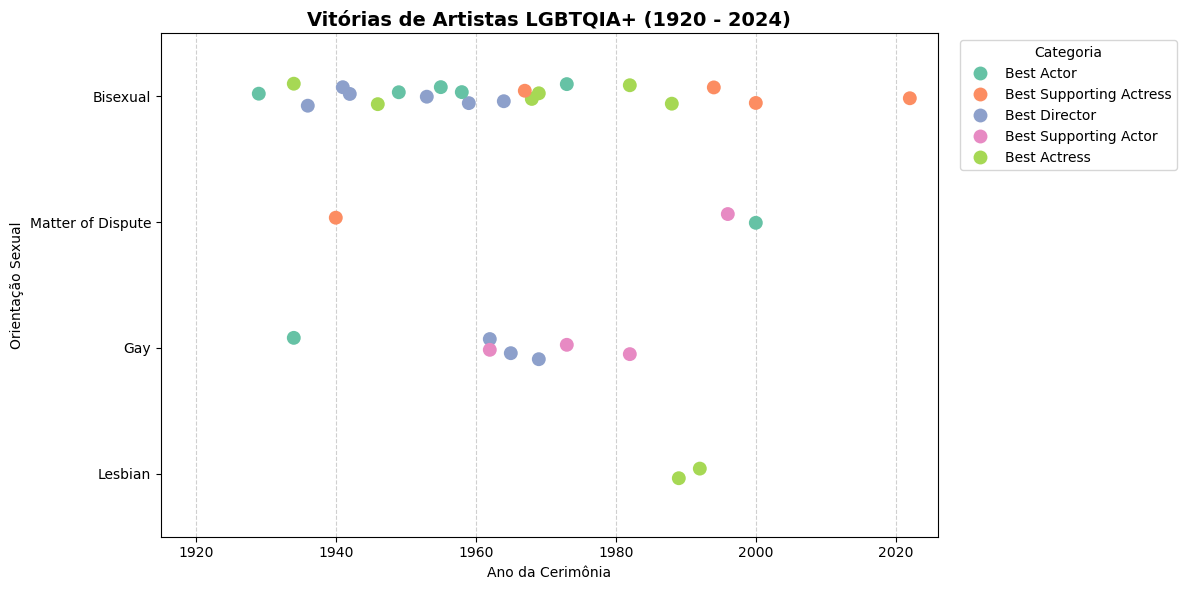

In [16]:
df_lgbt = df_valid[~df_valid['sexual_orientation'].str.strip().str.capitalize().isin(['Unknown', 'Straight', 'Na', 'Nan'])]

plt.figure(figsize=(12, 6))

sns.stripplot(
    data=df_lgbt, 
    x='year_edition', 
    y='sexual_orientation', 
    hue='category', 
    palette='Set2', 
    size=10,
    jitter=True 
)

plt.title('Vitórias de Artistas LGBTQIA+ (1920 - 2024)', fontsize=14, fontweight='bold')
plt.xlabel('Ano da Cerimônia')
plt.ylabel('Orientação Sexual')
plt.xlim(1915, 2026) 

plt.legend(title='Categoria', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.grid(True, axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

Para analisar se a inclusão gera retorno financeiro, calculamos o lucro limpo (Lucro bruto - Orçamento) de cada filme. Utilizaremos a mediana para evitar distorções e ter uma visão realista de qual grupo tende a lucrar mais de forma consistente

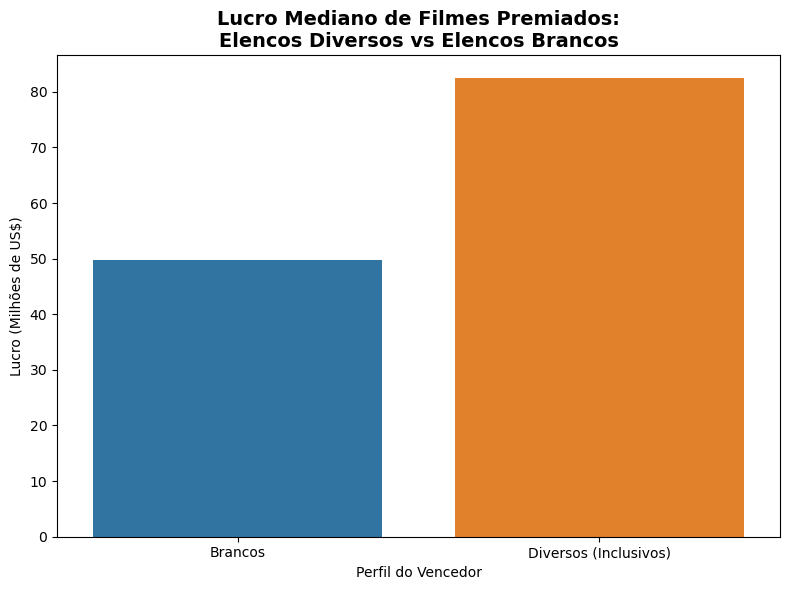

In [28]:
df_valid['perfil_racial'] = df_valid['race_ethnicity'].apply(
    lambda x: 'Brancos' if str(x).strip().lower() == 'white' else 'Diversos (Inclusivos)'
)
df_valid['orcamento'] = pd.to_numeric(df_valid['budget'].astype(str).str.replace(r'[^\d.]', '', regex=True), errors='coerce')
df_valid['bilheteria'] = pd.to_numeric(df_valid['gross_world_wide'].astype(str).str.replace(r'[^\d.]', '', regex=True), errors='coerce')

df_valid['lucro_milhoes'] = (df_valid['bilheteria'] - df_valid['orcamento']) / 1_000_000

df_financeiro = df_valid.dropna(subset=['lucro_milhoes'])

plt.figure(figsize=(8, 6))

sns.barplot(
    data=df_financeiro, 
    x='perfil_racial', 
    y='lucro_milhoes', 
    hue='perfil_racial',
    estimator=np.median,            
    legend=False,
    errorbar=None
)

plt.title('Lucro Mediano de Filmes Premiados:\nElencos Diversos vs Elencos Brancos', fontsize=14, fontweight='bold')
plt.xlabel('Perfil do Vencedor')
plt.ylabel('Lucro (Milhões de US$)')
plt.tight_layout()
plt.show()